In [ ]:
!pip install librosa soundfile numpy

# Normalisasi Audio

In [ ]:
import librosa
import numpy as np
import soundfile as sf

# --------------------------------------------------
# Fungsi: load dan normalisasi audio
# --------------------------------------------------
def load_and_normalize(path):

    audio, sr = librosa.load(path, sr=None)

    audio_norm = audio / np.max(np.abs(audio))

    return audio, audio_norm, sr

# --------------------------------------------------
# File 432 Hz dan 440 Hz
# --------------------------------------------------
file_432 = "/content/432 Hz .wav"
file_440 = "/content/440 Hz .wav"

audio_432, audio_432_norm, sr_432 = load_and_normalize(file_432)
sf.write("432_normalized.wav", audio_432_norm, sr_432)

audio_440, audio_440_norm, sr_440 = load_and_normalize(file_440)
sf.write("440_normalized.wav", audio_440_norm, sr_440)

# --------------------------------------------------
# Informasi hasil
# --------------------------------------------------
print("=== HASIL PEMROSESAN AUDIO ===")
print(f"File 432 Hz  | SR = {sr_432}, Durasi = {len(audio_432)/sr_432:.2f} detik")
print(f"File 440 Hz  | SR = {sr_440}, Durasi = {len(audio_440)/sr_440:.2f} detik")
print("Kedua file sudah dinormalisasi dan disimpan ulang.")

=== HASIL PEMROSESAN AUDIO ===
File 432 Hz  | SR = 44100, Durasi = 7.13 detik
File 440 Hz  | SR = 44100, Durasi = 7.25 detik
Kedua file sudah dinormalisasi dan disimpan ulang.


# Segmentasi

In [ ]:
import librosa
import numpy as np
import soundfile as sf
import os

# -------------------------------------------------
# Fungsi segmentasi audio
# -------------------------------------------------
def segment_audio(file_path, output_dir, segment_duration=5):

    audio, sr = librosa.load(file_path, sr=None)

    samples_per_segment = segment_duration * sr

    os.makedirs(output_dir, exist_ok=True)

    total_segments = int(len(audio) / samples_per_segment)

    print(f"\nMemproses file: {file_path}")
    print(f"Sampling Rate: {sr}")
    print(f"Total segmen: {total_segments}")

    for i in range(total_segments):
        start = i * samples_per_segment
        end = start + samples_per_segment
        segment = audio[start:end]

        segment_norm = segment / np.max(np.abs(segment))

        out_file = os.path.join(output_dir, f"segment_{i+1}.wav")

        sf.write(out_file, segment_norm, sr)

    print(f"Segmentasi selesai, hasil disimpan di folder: {output_dir}")
    return total_segments


# -------------------------------------------------
# 1) File WAV 432 Hz
# -------------------------------------------------
file_432 = "432_normalized.wav"
output_dir_432 = "segments_432"

segment_audio(file_432, output_dir_432, segment_duration=5)


# -------------------------------------------------
# 2) File WAV 440 Hz
# -------------------------------------------------
file_440 = "440_normalized.wav"
output_dir_440 = "segments_440"

segment_audio(file_440, output_dir_440, segment_duration=5)



Memproses file: 432_normalized.wav
Sampling Rate: 44100
Total segmen: 1
Segmentasi selesai, hasil disimpan di folder: segments_432

Memproses file: 440_normalized.wav
Sampling Rate: 44100
Total segmen: 1
Segmentasi selesai, hasil disimpan di folder: segments_440


1

# FFT

In [ ]:
!pip install numpy librosa pandas matplotlib

In [ ]:
import os
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt

def compute_fft(audio, sr):
    n = len(audio)
    fft_spectrum = np.fft.fft(audio)
    freq = np.fft.fftfreq(n, d=1/sr)
    magnitude = np.abs(fft_spectrum)[:n//2]
    freq = freq[:n//2]

    return freq, magnitude

def process_segments_fft(folder_path, label):
    results = []
    file_list = sorted(os.listdir(folder_path))
    for i, file_name in enumerate(file_list):
        if not file_name.endswith(".wav"):
            continue
        path = os.path.join(folder_path, file_name)
        audio, sr = librosa.load(path, sr=None)

        freq, mag = compute_fft(audio, sr)
        dominant_freq = freq[np.argmax(mag)]

        results.append({
            "segment": file_name,
            "dominant_frequency": dominant_freq,
            "label": label
        })

        print(f"{label} - {file_name}: Dominan = {dominant_freq:.2f} Hz")

    return pd.DataFrame(results)

folder_432 = "/content/segments_432"
folder_440 = "/content/segments_440"

df_432 = process_segments_fft(folder_432, "432Hz")
df_440 = process_segments_fft(folder_440, "440Hz")

df_all = pd.concat([df_432, df_440], axis=0)
df_all.to_csv("hasil_fft.csv", index=False)

print("\nHasil FFT disimpan ke 'hasil_fft.csv'")


432Hz - segment_1.wav: Dominan = 432.00 Hz
440Hz - segment_1.wav: Dominan = 440.00 Hz

Hasil FFT disimpan ke 'hasil_fft.csv'


# Visualisasi FFT

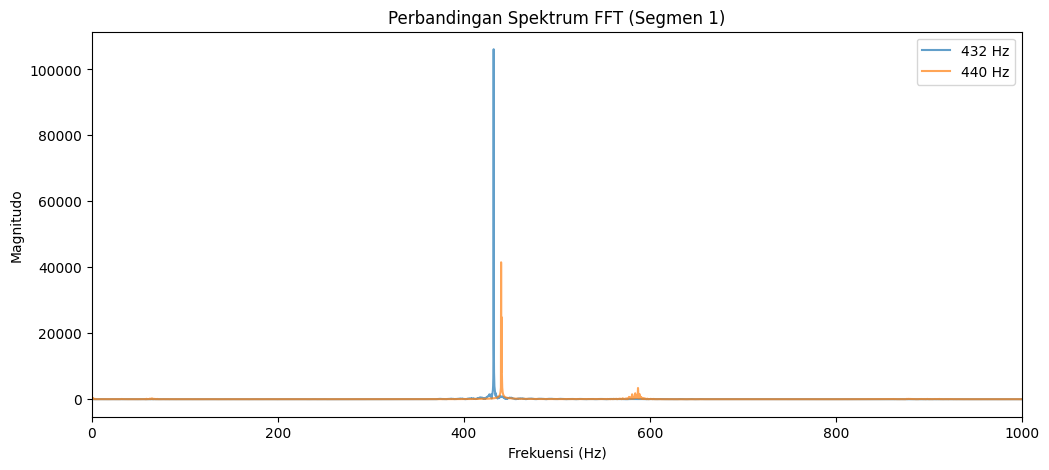

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os

def compute_fft(audio, sr):
    n = len(audio)
    fft = np.fft.fft(audio)
    freq = np.fft.fftfreq(n, 1/sr)
    mag = np.abs(fft)

    return freq[:n//2], mag[:n//2]


# ---------------------------
# Ambil segmen pertama
# ---------------------------
seg_432 = "segments_432/segment_1.wav"
seg_440 = "segments_440/segment_1.wav"

audio_432, sr_432 = librosa.load(seg_432, sr=None)
audio_440, sr_440 = librosa.load(seg_440, sr=None)

# FFT
freq_432, mag_432 = compute_fft(audio_432, sr_432)
freq_440, mag_440 = compute_fft(audio_440, sr_440)

# ---------------------------
# Plot FFT
# ---------------------------
plt.figure(figsize=(12, 5))
plt.plot(freq_432, mag_432, label="432 Hz", alpha=0.7)
plt.plot(freq_440, mag_440, label="440 Hz", alpha=0.7)
plt.xlim(0, 1000)
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Magnitudo")
plt.title("Perbandingan Spektrum FFT (Segmen 1)")
plt.legend()
plt.show()


In [ ]:
import numpy as np
from scipy.io import wavfile

def compute_peak_amplitude(file_path):
    sr, audio = wavfile.read(file_path)

    audio = audio.astype(np.float32)

    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    max_val = np.max(np.abs(audio))
    if max_val != 0:
        audio = audio / max_val

    # FFT
    fft_vals = np.fft.fft(audio)
    magnitude = np.abs(fft_vals)

    magnitude = magnitude[:len(magnitude)//2]

    peak_amplitude = np.max(magnitude)

    return peak_amplitude


print("Peak Amplitude 432 Hz:",
      compute_peak_amplitude("/content/segments_432/segment_1.wav"))

print("Peak Amplitude 440 Hz:",
      compute_peak_amplitude("/content/segments_440/segment_1.wav"))


Peak Amplitude 432 Hz: 106120.34
Peak Amplitude 440 Hz: 41515.082


*cek* amplitudo

In [ ]:
import numpy as np
from scipy.io import wavfile

def check_amplitude(file):
    sr, audio = wavfile.read(file)
    if len(audio.shape) > 1:
        audio = audio[:,0]
    return audio.max(), audio.min(), np.max(np.abs(audio))

file1 = "/content/segments_432/segment_1.wav"
file2 = "/content/segments_440/segment_1.wav"

print("432 amplitude:", check_amplitude(file1))
print("440 amplitude:", check_amplitude(file2))


432 amplitude: (np.int16(32731), np.int16(-32768), np.int16(32742))
440 amplitude: (np.int16(32767), np.int16(-30755), np.int16(32767))


cek FFT

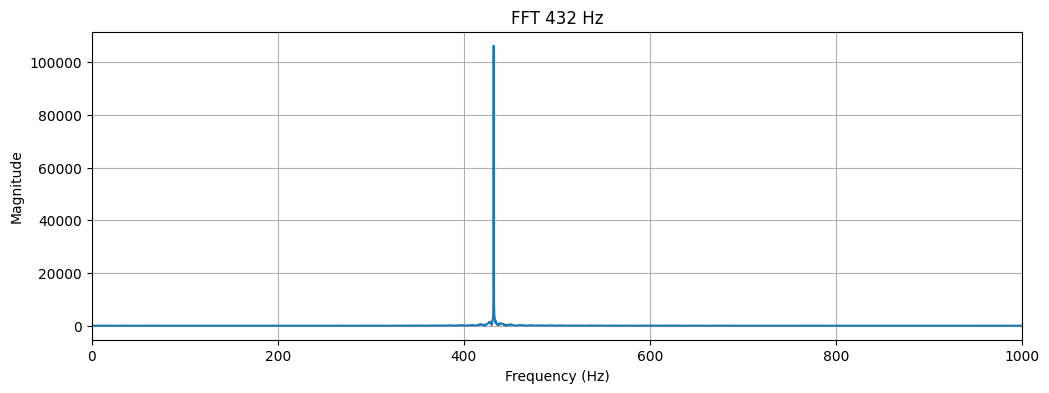

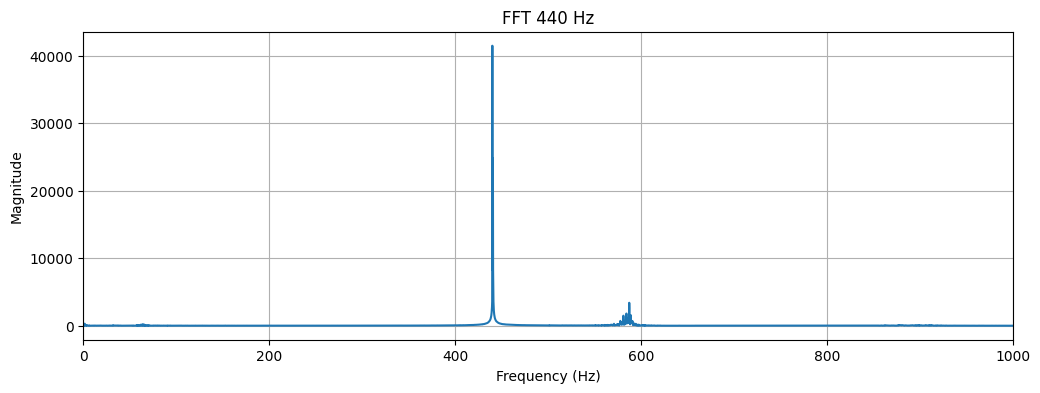

In [ ]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

def plot_fft(file, title):
    sr, audio = wavfile.read(file)
    if len(audio.shape) > 1:
        audio = audio[:,0]
    audio = audio / np.max(np.abs(audio))

    N = len(audio)
    fft_vals = np.fft.rfft(audio)
    freqs = np.fft.rfftfreq(N, 1/sr)

    plt.figure(figsize=(12,4))
    plt.plot(freqs, np.abs(fft_vals))
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 1000)
    plt.grid()
    plt.show()

plot_fft(file1, "FFT 432 Hz")
plot_fft(file2, "FFT 440 Hz")


CEK RMS, Total power dari FFT, proporsi sample cliping, DC offset, Parameter, dan Plot FFT ternormalisasi

In [ ]:
import pandas as pd

# =============================
# Data hasil perhitungan Anda
# =============================
data = {
    "Parameter": [
        "Total Power Ratio (440/432)",
        "RMS Ratio (440/432)",
        "Band Power - Delta (432)",
        "Band Power - Delta (440)",
        "Band Power - Theta (432)",
        "Band Power - Theta (440)",
        "Band Power - Alpha (432)",
        "Band Power - Alpha (440)",
        "Band Power - Beta (432)",
        "Band Power - Beta (440)",
        "Band Power - Gamma (432)",
        "Band Power - Gamma (440)",
        "Gamma Ratio (440/432)"
    ],
    "Value": [
        0.304,     # Total power ratio
        0.524,     # RMS ratio
        0,         # Delta 432
        0,         # Delta 440
        0,         # Theta 432
        0,         # Theta 440
        0,         # Alpha 432
        0,         # Alpha 440
        0,         # Beta 432
        0,         # Beta 440
        262.612446,  # Gamma 432
        16099.70307, # Gamma 440
        16099.70307 / 262.612446   # Gamma ratio
    ]
}

df = pd.DataFrame(data)

output_path = "hasil_perbandingan.csv"
df.to_csv(output_path, index=False)

print("CSV berhasil dibuat:", output_path)


CSV berhasil dibuat: hasil_perbandingan.csv


# HASIL


--- 432Hz ---
SR: 44100, samples: 220500, dur(s): 5.000
peak_pos: 32731.0, peak_neg: -32768.0, peak_abs: 32768.0
mean (DC offset): 2.130753, RMS: 23016.123516, P2P: 65499.0
clipped_ratio (prop. samples exactly at peak): 0.000009
Total PSD power (integral over all freqs): 4.398558e-01
  delta  power: 0.000000e+00   (0.0000% of total)
  theta  power: 0.000000e+00   (0.0000% of total)
  alpha  power: 0.000000e+00   (0.0000% of total)
  beta   power: 0.000000e+00   (0.0000% of total)
  gamma  power: 2.445769e-07   (0.0001% of total)

--- 440Hz ---
SR: 44100, samples: 220500, dur(s): 5.000
peak_pos: 32767.0, peak_neg: -30755.0, peak_abs: 32767.0
mean (DC offset): -0.275796, RMS: 12068.991216, P2P: 63522.0
clipped_ratio (prop. samples exactly at peak): 0.000009
Total PSD power (integral over all freqs): 1.335187e-01
  delta  power: 0.000000e+00   (0.0000% of total)
  theta  power: 0.000000e+00   (0.0000% of total)
  alpha  power: 0.000000e+00   (0.0000% of total)
  beta   power: 0.000000e+0

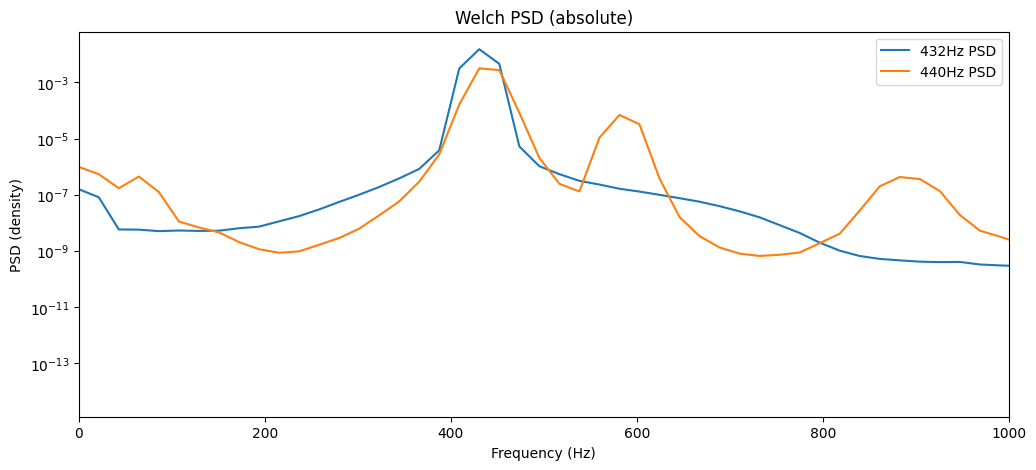

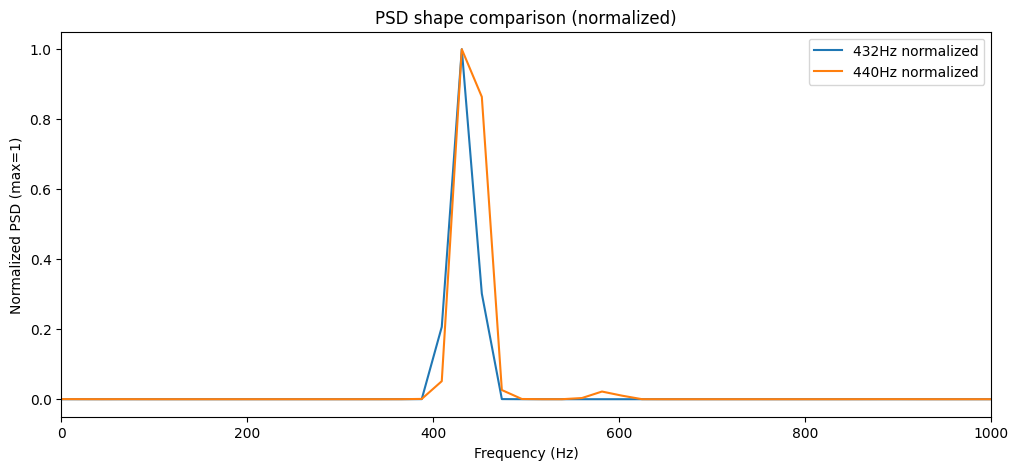

In [ ]:
import numpy as np
from scipy.io import wavfile
from scipy.signal import welch
from scipy.integrate import simpson
import matplotlib.pyplot as plt

file_432 = "/content/segments_432/segment_1.wav"
file_440 = "/content/segments_440/segment_1.wav"

def load_mono(path):
    sr, audio = wavfile.read(path)

    audio = audio.astype(float)

    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)
    return sr, audio

def diagnostics(path, label):
    sr, audio = load_mono(path)

    peak_pos = np.max(audio)
    peak_neg = np.min(audio)
    peak_abs = np.max(np.abs(audio))
    mean_val = np.mean(audio)
    rms = np.sqrt(np.mean(audio**2))
    p2p = peak_pos - peak_neg
    clipped_ratio = np.mean(np.isclose(audio, peak_pos) | np.isclose(audio, peak_neg))
    print(f"\n--- {label} ---")
    print(f"SR: {sr}, samples: {len(audio)}, dur(s): {len(audio)/sr:.3f}")
    print(f"peak_pos: {peak_pos}, peak_neg: {peak_neg}, peak_abs: {peak_abs}")
    print(f"mean (DC offset): {mean_val:.6f}, RMS: {rms:.6f}, P2P: {p2p}")
    print(f"clipped_ratio (prop. samples exactly at peak): {clipped_ratio:.6f}")

    if peak_abs > 0:
        audio_norm = audio / peak_abs
    else:
        audio_norm = audio.copy()

    # PSD (Welch) - consistent params
    nperseg = 2048
    freqs, Pxx = welch(audio_norm, fs=sr, nperseg=nperseg, window='hann', scaling='density')
    total_power = simpson(Pxx, freqs)
    bands = {
        "delta": (0.5, 4),
        "theta": (4, 8),
        "alpha": (8, 12),
        "beta": (12, 30),
        "gamma": (30, 100),
    }
    band_powers = {}
    for k,(lo,hi) in bands.items():
        idx = np.logical_and(freqs >= lo, freqs <= hi)
        band_powers[k] = simpson(Pxx[idx], freqs[idx]) if np.any(idx) else 0.0

    print(f"Total PSD power (integral over all freqs): {total_power:.6e}")
    for k,v in band_powers.items():
        print(f"  {k:6s} power: {v:.6e}   ({(v/total_power*100 if total_power>0 else 0):.4f}% of total)")

    return sr, audio_norm, freqs, Pxx, total_power

sr1, a1, f1, P1, tot1 = diagnostics(file_432, "432Hz")
sr2, a2, f2, P2, tot2 = diagnostics(file_440, "440Hz")

print("\n=== COMPARISON SUMMARY ===")
print(f"Total power ratio 440/432 = {tot2/tot1 if tot1>0 else np.inf:.3f}")
print(f"RMS ratio 440/432 = { (np.sqrt(np.mean(a2**2)) / np.sqrt(np.mean(a1**2))) if np.mean(a1**2)>0 else np.inf :.3f}")

plt.figure(figsize=(12,5))
plt.semilogy(f1, P1, label='432Hz PSD')
plt.semilogy(f2, P2, label='440Hz PSD')
plt.xlim(0,1000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (density)")
plt.legend()
plt.title("Welch PSD (absolute)")

plt.figure(figsize=(12,5))
plt.plot(f1, P1/np.max(P1), label='432Hz normalized')
plt.plot(f2, P2/np.max(P2), label='440Hz normalized')
plt.xlim(0,1000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized PSD (max=1)")
plt.legend()
plt.title("PSD shape comparison (normalized)")
plt.show()

if tot2 > 0 and tot1 > 0:
    if tot2/tot1 > 5:
        print("\nNote: total PSD differs greatly. Try RMS-normalization before PSD as alternative:")

        a1_rms = a1 / np.sqrt(np.mean(a1**2))
        a2_rms = a2 / np.sqrt(np.mean(a2**2))
        f1b, P1b = welch(a1_rms, fs=sr1, nperseg=2048, window='hann', scaling='density')
        f2b, P2b = welch(a2_rms, fs=sr2, nperseg=2048, window='hann', scaling='density')
        tot1b = simpson(P1b, f1b)
        tot2b = simpson(P2b, f2b)
        print(f"After RMS-normalize total power ratio 440/432 = {tot2b/tot1b if tot1b>0 else np.inf:.3f}")
        plt.figure(figsize=(10,4))
        plt.plot(f1b, P1b/np.max(P1b), label='432Hz RMS-norm')
        plt.plot(f2b, P2b/np.max(P2b), label='440Hz RMS-norm')
        plt.xlim(0,1000)
        plt.legend()
        plt.title("PSD after RMS normalization (shape)")
        plt.show()


FFT 432 Hz
Peak Frequency  : 432.00 Hz
Peak Amplitude  : 106204.6137



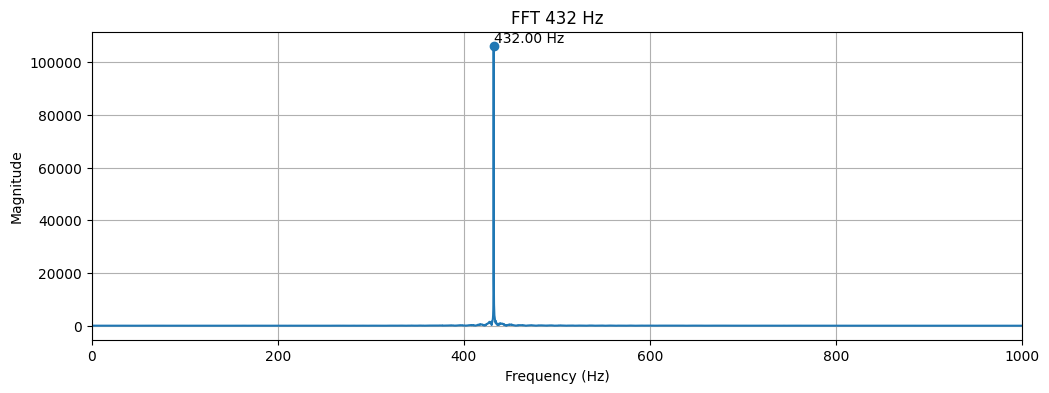

FFT 440 Hz
Peak Frequency  : 440.00 Hz
Peak Amplitude  : 41515.0787



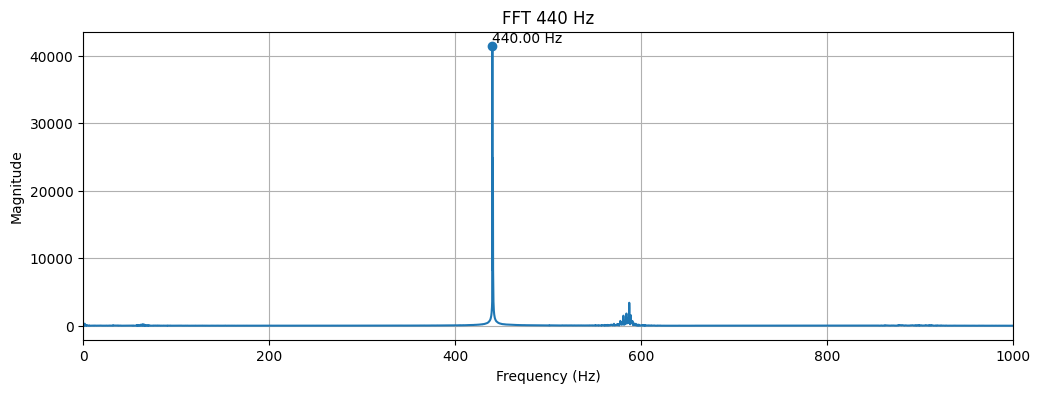

In [ ]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

def plot_fft_with_peak(file, title):
    sr, audio = wavfile.read(file)
    if len(audio.shape) > 1:
        audio = audio[:,0]
    audio = audio / np.max(np.abs(audio))

    N = len(audio)
    fft_vals = np.fft.rfft(audio)
    freqs = np.fft.rfftfreq(N, 1/sr)
    magnitude = np.abs(fft_vals)

    peak_index = np.argmax(magnitude)
    peak_freq = freqs[peak_index]
    peak_amplitude = magnitude[peak_index]

    print(f"{title}")
    print(f"Peak Frequency  : {peak_freq:.2f} Hz")
    print(f"Peak Amplitude  : {peak_amplitude:.4f}\n")

    plt.figure(figsize=(12,4))
    plt.plot(freqs, magnitude)
    plt.scatter(peak_freq, peak_amplitude, marker='o')
    plt.text(peak_freq, peak_amplitude, f"{peak_freq:.2f} Hz", verticalalignment='bottom')
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 1000)
    plt.grid()
    plt.show()

plot_fft_with_peak(file1, "FFT 432 Hz")
plot_fft_with_peak(file2, "FFT 440 Hz")


# PSD (POWER SPECTRUM DENSITY)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch


fs_432, audio_432 = wavfile.read('/content/segments_432/segment_1.wav')
fs_440, audio_440 = wavfile.read('/content/segments_440/segment_1.wav')

if len(audio_432.shape) > 1:
    audio_432 = audio_432.mean(axis=1)

if len(audio_440.shape) > 1:
    audio_440 = audio_440.mean(axis=1)

audio_432 = audio_432 / np.max(np.abs(audio_432))
audio_440 = audio_440 / np.max(np.abs(audio_440))


psd_freq_432, psd_vals_432 = welch(audio_432, fs_432, nperseg=4096)
psd_freq_440, psd_vals_440 = welch(audio_440, fs_440, nperseg=4096)

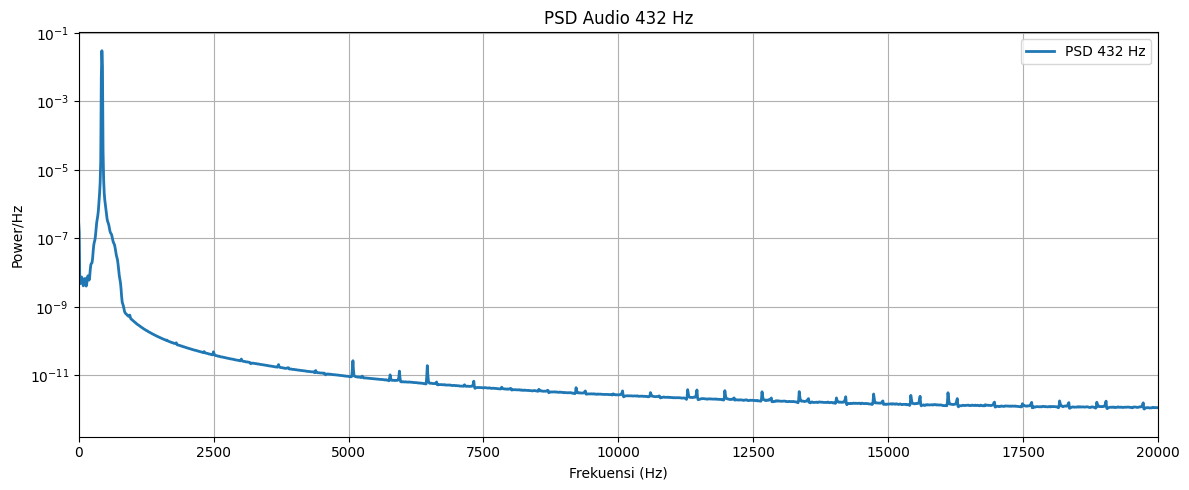

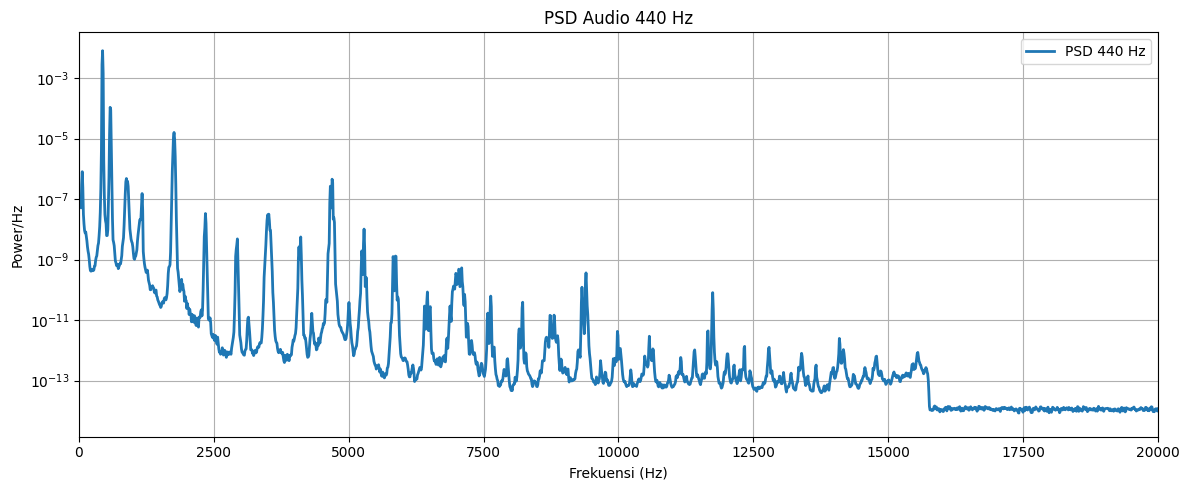

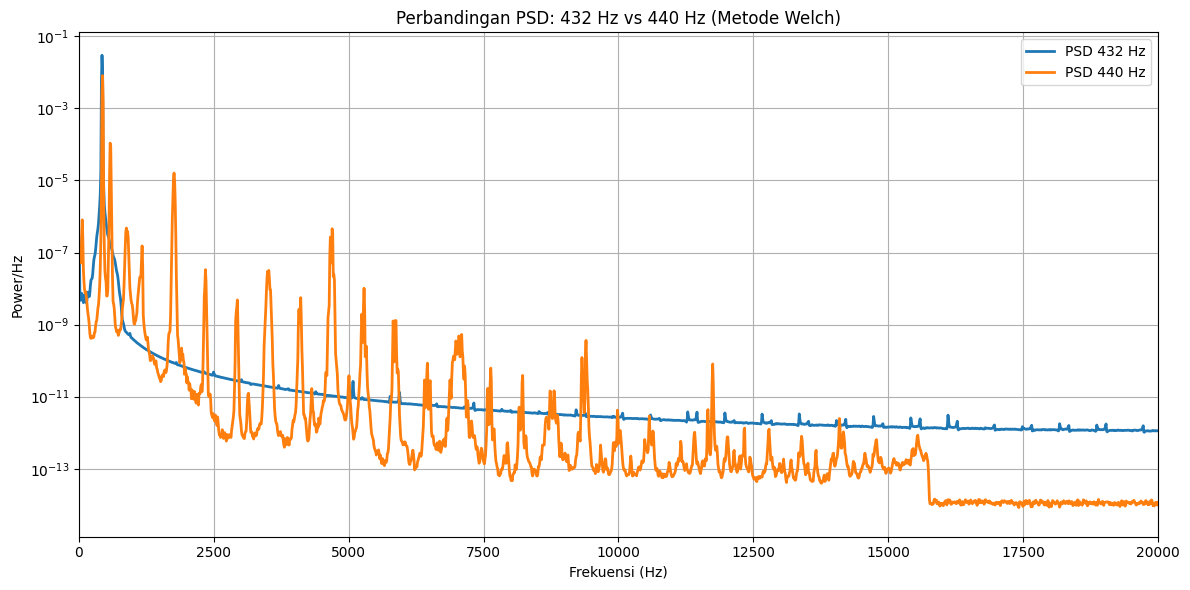

In [ ]:

plt.figure(figsize=(12,5))
plt.semilogy(psd_freq_432, psd_vals_432, label='PSD 432 Hz', linewidth=2)
plt.xlim(0, 20000)
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Power/Hz")
plt.title("PSD Audio 432 Hz")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.semilogy(psd_freq_440, psd_vals_440, label='PSD 440 Hz', linewidth=2)
plt.xlim(0, 20000)
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Power/Hz")
plt.title("PSD Audio 440 Hz")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.semilogy(psd_freq_432, psd_vals_432, label='PSD 432 Hz', linewidth=2)
plt.semilogy(psd_freq_440, psd_vals_440, label='PSD 440 Hz', linewidth=2)
plt.xlim(0, 20000)
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Power/Hz")
plt.title("Perbandingan PSD: 432 Hz vs 440 Hz (Metode Welch)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#Zoom PSD 300–700 Hz


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch, find_peaks
import pandas as pd
import os

file_432 = '/content/segments_432/segment_1.wav'
file_440 = '/content/segments_440/segment_1.wav'
out_dir = 'results_psd'
os.makedirs(out_dir, exist_ok=True)


In [ ]:
fs_432, audio_432 = wavfile.read(file_432)
fs_440, audio_440 = wavfile.read(file_440)

def mono_float(x):
    x = x.astype(np.float64)
    if x.ndim > 1:
        x = x.mean(axis=1)
    if np.max(np.abs(x)) > 0:
        x = x / np.max(np.abs(x))
    return x

audio_432 = mono_float(audio_432)
audio_440 = mono_float(audio_440)


In [ ]:
nperseg = 4096

psd_freq_432, psd_vals_432 = welch(audio_432, fs_432, nperseg=min(nperseg, len(audio_432)))
psd_freq_440, psd_vals_440 = welch(audio_440, fs_440, nperseg=min(nperseg, len(audio_440)))


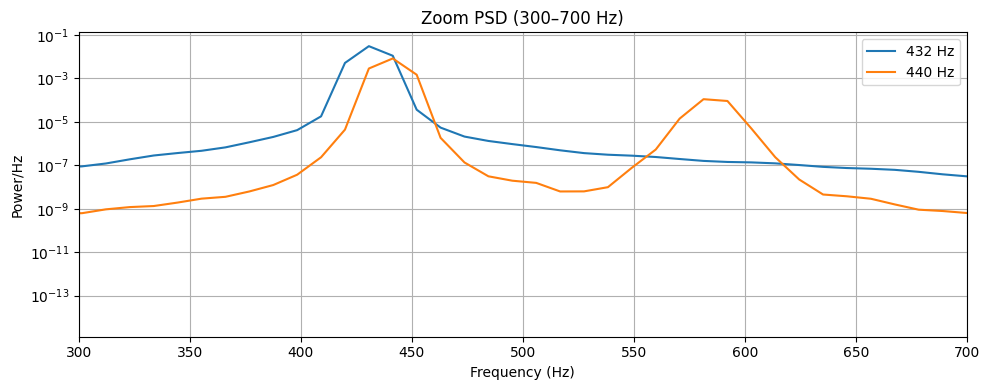

In [ ]:
plt.figure(figsize=(10,4))
plt.semilogy(psd_freq_432, psd_vals_432, label='432 Hz')
plt.semilogy(psd_freq_440, psd_vals_440, label='440 Hz')
plt.xlim(300,700)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Hz')
plt.title('Zoom PSD (300–700 Hz)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'PSD_zoom_300_700.png'), dpi=200)
plt.show()


# BAND-POWER ANALISIS


In [ ]:
def band_power(freq, psd, f_low, f_high):
    mask = (freq >= f_low) & (freq <= f_high)
    if not np.any(mask):
        return 0.0
    return np.trapezoid(psd[mask], freq[mask])

bp_0_1k_432 = band_power(psd_freq_432, psd_vals_432, 0, 1000)
bp_0_1k_440 = band_power(psd_freq_440, psd_vals_440, 0, 1000)
bp_1_5k_432 = band_power(psd_freq_432, psd_vals_432, 1000, 5000)
bp_1_5k_440 = band_power(psd_freq_440, psd_vals_440, 1000, 5000)

print("Band-Power 0–1 kHz (432):", bp_0_1k_432)
print("Band-Power 0–1 kHz (440):", bp_0_1k_440)
print("Band-Power 1–5 kHz (432):", bp_1_5k_432)
print("Band-Power 1–5 kHz (440):", bp_1_5k_440)


Band-Power 0–1 kHz (432): 0.4935124251893761
Band-Power 0–1 kHz (440): 0.13580601283108223
Band-Power 1–5 kHz (432): 2.279416915596974e-07
Band-Power 1–5 kHz (440): 0.0004990011856231596


#BAR CHART BAND-POWER

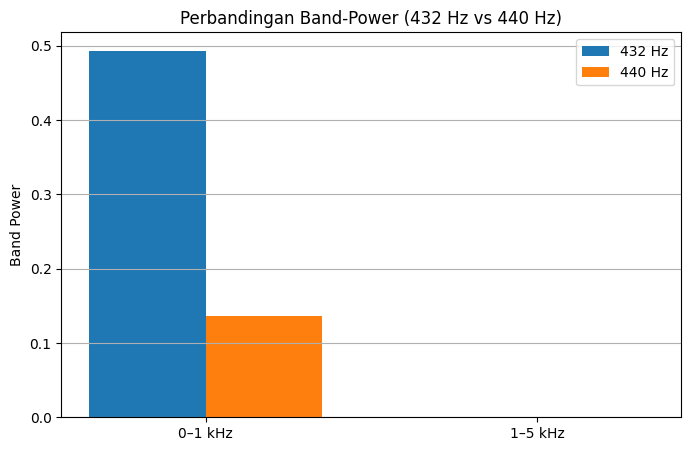

In [ ]:
import pandas as pd
import numpy as np

labels = ['0–1 kHz', '1–5 kHz']
band_432 = [bp_0_1k_432, bp_1_5k_432]
band_440 = [bp_0_1k_440, bp_1_5k_440]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, band_432, width, label='432 Hz')
plt.bar(x + width/2, band_440, width, label='440 Hz')
plt.xticks(x, labels)
plt.ylabel("Band Power")
plt.title("Perbandingan Band-Power (432 Hz vs 440 Hz)")
plt.legend()
plt.grid(axis='y')
plt.show()

# PEAK DETECTION / HARMONIC ANALYSIS

In [ ]:
threshold_factor = 0.05

peaks_432, props_432 = find_peaks(psd_vals_432, height=np.max(psd_vals_432)*threshold_factor)
peaks_440, props_440 = find_peaks(psd_vals_440, height=np.max(psd_vals_440)*threshold_factor)

peak_freqs_432 = psd_freq_432[peaks_432]
peak_vals_432 = psd_vals_432[peaks_432]
peak_freqs_440 = psd_freq_440[peaks_440]
peak_vals_440 = psd_vals_440[peaks_440]

print("\nPeaks PSD (432) count:", len(peak_freqs_432))
print("Peak freqs (432):", np.round(peak_freqs_432, 3))
print("Peaks PSD (440) count:", len(peak_freqs_440))
print("Peak freqs (440):", np.round(peak_freqs_440, 3))



Peaks PSD (432) count: 1
Peak freqs (432): [430.664]
Peaks PSD (440) count: 1
Peak freqs (440): [441.431]


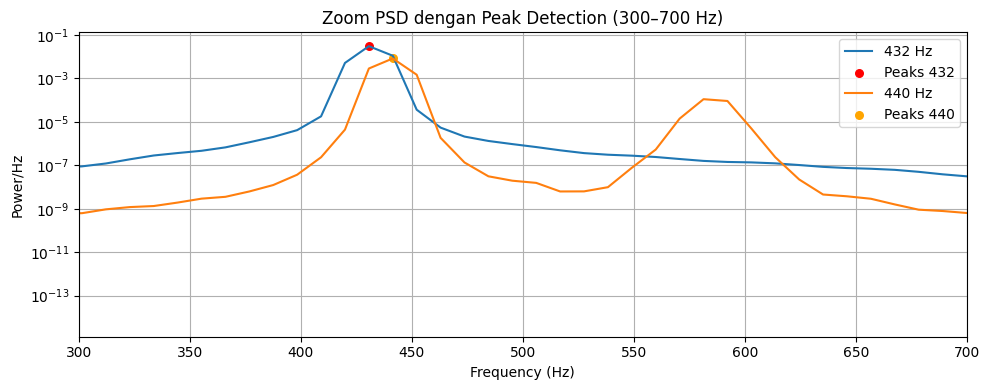

In [ ]:
plt.figure(figsize=(10,4))
plt.semilogy(psd_freq_432, psd_vals_432, label='432 Hz')
plt.scatter(peak_freqs_432, peak_vals_432, color='red', s=30, label='Peaks 432')

plt.semilogy(psd_freq_440, psd_vals_440, label='440 Hz')
plt.scatter(peak_freqs_440, peak_vals_440, color='orange', s=30, label='Peaks 440')

plt.xlim(300,700)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Hz')
plt.title('Zoom PSD dengan Peak Detection (300–700 Hz)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'PSD_zoom_with_peaks.png'), dpi=200)
plt.show()


# tabel hasil


In [ ]:
import numpy as np
import pandas as pd
from scipy.io import wavfile
from scipy.signal import welch

# -------------------------
# HELPER FUNCTIONS
# -------------------------

def load_audio(path):
    sr, audio = wavfile.read(path)
    if len(audio.shape) > 1:
        audio = audio[:, 0]
    audio = audio.astype(float)
    audio = audio / np.max(np.abs(audio))
    return sr, audio

def peak_amplitude(audio):
    return float(np.max(audio)), float(np.min(audio)), float(np.max(np.abs(audio)))

def fft_features(audio, sr):
    N = len(audio)
    freqs = np.fft.rfftfreq(N, 1/sr)
    fft_vals = np.abs(np.fft.rfft(audio))

    dominant_freq = freqs[np.argmax(fft_vals)]
    total_power = np.sum(fft_vals**2)
    return float(dominant_freq), float(total_power)

def psd_energy(audio, sr):
    freqs, psd = welch(audio, sr, nperseg=1024)
    return float(np.sum(psd))

def bandpower(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    return float(np.trapz(psd[mask], freqs[mask]))

def compute_band_power(audio, sr):
    freqs, psd = welch(audio, sr, nperseg=1024)

    bands = {
        "delta": (0.5, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta":  (13, 30),
        "gamma": (30, 100)
    }

    return {band: bandpower(freqs, psd, lo, hi) for band, (lo, hi) in bands.items()}

# -------------------------
# MAIN PROCESSING
# -------------------------

file_432 = "/content/segments_432/segment_1.wav"
file_440 = "/content/segments_440/segment_1.wav"

results = {}

for label, file in [("432 Hz", file_432), ("440 Hz", file_440)]:
    sr, audio = load_audio(file)

    max_amp, min_amp, peak = peak_amplitude(audio)
    dom_freq, total_fft_power = fft_features(audio, sr)
    psd_energy_val = psd_energy(audio, sr)

    bp = compute_band_power(audio, sr)

    results[label] = {
        "Max Amplitude": max_amp,
        "Min Amplitude": min_amp,
        "Peak Absolute": peak,
        "Dominant FFT Frequency": dom_freq,
        "Total FFT Power": total_fft_power,
        "Total PSD Energy": psd_energy_val,
        "Band Δ": bp["delta"],
        "Band θ": bp["theta"],
        "Band α": bp["alpha"],
        "Band β": bp["beta"],
        "Band γ": bp["gamma"],
    }

df = pd.DataFrame(results).T
df.to_csv("hasil_final.csv", index=True)

df


/tmp/ipython-input-1203108220.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[mask], freqs[mask]))


,Max Amplitude,Min Amplitude,Peak Absolute,Dominant FFT Frequency,Total FFT Power,Total PSD Energy,Band Δ,Band θ,Band α,Band β,Band γ
432 Hz,0.998871,-1.000000,1.0,432.0,1.199366e+10,0.011459,0.0,0.0,0.0,0.0,0.000001
440 Hz,1.000000,-0.938597,1.0,440.0,3.298039e+09,0.003156,0.0,0.0,0.0,0.0,0.000017


Play Audio 432 Hz:


Play Audio 440 Hz:


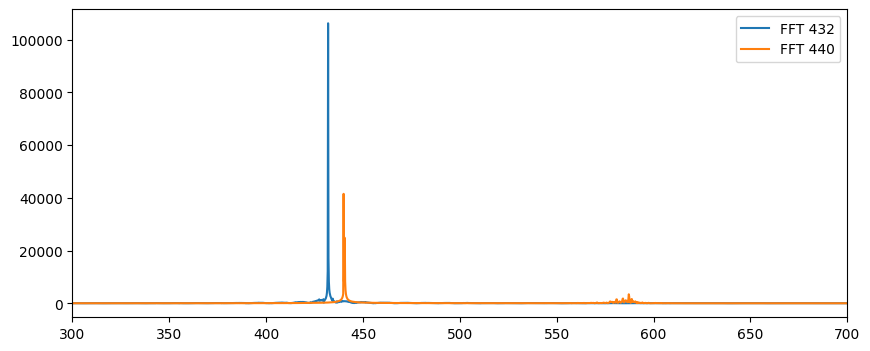

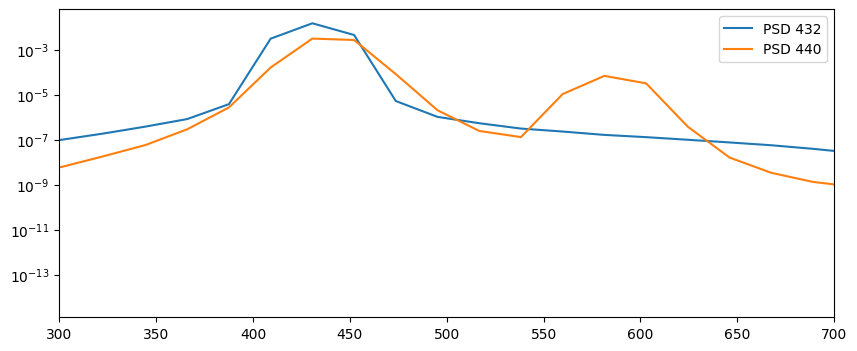

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch
from IPython.display import Audio


sr_432, audio_432 = wavfile.read('/content/segments_432/segment_1.wav')
sr_440, audio_440 = wavfile.read('/content/segments_440/segment_1.wav')

audio_432 = audio_432.astype(float) / np.max(np.abs(audio_432))
audio_440 = audio_440.astype(float) / np.max(np.abs(audio_440))

print("Play Audio 432 Hz:")
display(Audio('/content/segments_432/segment_1.wav'))

print("Play Audio 440 Hz:")
display(Audio('/content/segments_440/segment_1.wav'))

# ==== FFT ====
def compute_fft(audio, sr):
    N = len(audio)
    freqs = np.fft.rfftfreq(N, 1/sr)
    fft_vals = np.abs(np.fft.rfft(audio))
    return freqs, fft_vals

freqs_432, fft_432 = compute_fft(audio_432, sr_432)
freqs_440, fft_440 = compute_fft(audio_440, sr_440)

# ==== PSD ====
freq_psd_432, psd_432 = welch(audio_432, sr_432, nperseg=2048)
freq_psd_440, psd_440 = welch(audio_440, sr_440, nperseg=2048)

# ==== PLOT ====
plt.figure(figsize=(10,4))
plt.plot(freqs_432, fft_432, label='FFT 432')
plt.plot(freqs_440, fft_440, label='FFT 440')
plt.xlim(300,700)
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.semilogy(freq_psd_432, psd_432, label='PSD 432')
plt.semilogy(freq_psd_440, psd_440, label='PSD 440')
plt.xlim(300,700)
plt.legend()
plt.show()

# cara menggunakan dalam kehidupan nyata

In [ ]:
from google.colab import drive
import pandas as pd
import os

# ======================
# 1. MOUNT GOOGLE DRIVE
# ======================
drive.mount('/content/drive')

# ======================
# 2. SETUP FOLDER DI SHARED DRIVE
# ======================

shared_drive_name = "jurnal psd"
folder_path = f"/content/drive/Shareddrives/jurnal psd"

os.makedirs(folder_path, exist_ok=True)

file_path = f"{folder_path}/PSD.csv"

# ======================
# 3. LOAD DATA LAMA JIKA ADA
# ======================

if os.path.isfile(file_path):
    df_existing = pd.read_csv(file_path)
else:
    df_existing = pd.DataFrame()

# ======================
# 4. INPUT MULTIPLE DATA SEKALI RUN
# ======================

print("Input data kecemasan.\nKetik 'stop' pada ID Subjek untuk berhenti.\n")

new_rows = []

while True:
    subject = input("Nama: ")

    if subject.lower() == "stop":
        break

    condition = input("Kondisi (432/440): ")
    pre = float(input("Skor STAI-X1 SEBELUM: "))
    post = float(input("Skor STAI-X1 SESUDAH: "))
    age = input("Usia: ")
    sex = input("Jenis kelamin (M/F): ")

    new_rows.append({
        "subject": subject,
        "condition": int(condition),
        "pre": pre,
        "post": post,
        "delta": pre - post,
        "age": age,
        "sex": sex
    })

    print("Data tersimpan sementara. Isi lagi atau ketik 'stop'.\n")

# ======================
# 5. GABUNGKAN DATA LAMA + BARU
# ======================

df_new = pd.DataFrame(new_rows)

df_final = pd.concat([df_existing, df_new], ignore_index=True)

# SIMPAN KE CSV
df_final.to_csv(file_path, index=False)

print("\nSemua data berhasil disimpan ke:", file_path)
df_final


Mounted at /content/drive
Input data kecemasan.
Ketik 'stop' pada ID Subjek untuk berhenti.

Nama: dar
Kondisi (432/440): 432
Skor STAI-X1 SEBELUM: 20
Skor STAI-X1 SESUDAH: 21
Usia: 20
Jenis kelamin (M/F): f
Data tersimpan sementara. Isi lagi atau ketik 'stop'.

Nama: stop

Semua data berhasil disimpan ke: /content/drive/Shareddrives/jurnal psd/PSD.csv


,subject,condition,pre,post,delta,age,sex
0,Fitri,432,20.0,15.0,5.0,20,F
1,1,432,20.0,15.0,5.0,20,F
2,FITRI,432,20.0,15.0,5.0,20,F
3,CONTOH,440,34.0,30.0,4.0,35,M
4,dar,432,20.0,21.0,-1.0,20,f


In [ ]:
from google.colab import drive
import pandas as pd
import os

# ================================================
# 1. MOUNT GOOGLE DRIVE
# ================================================
drive.mount('/content/drive')

# ================================================
# 2. SETUP FOLDER PENYIMPANAN CSV
# ================================================
shared_drive_name = "jurnal psd"
folder_path = f"/content/drive/Shareddrives/jurnal psd"
os.makedirs(folder_path, exist_ok=True)

file_path = f"{folder_path}/STAI_Data.csv"

# ================================================
# 3. LOAD DATA LAMA
# ================================================
if os.path.isfile(file_path):
    df_existing = pd.read_csv(file_path)
else:
    df_existing = pd.DataFrame()

# ================================================
# 4. DEFINISI ITEM STAI + SCORING
# ================================================

item_text = {
    1: "Saya merasa tenang",
    2: "Saya merasa aman",
    3: "Saya tegang (R)",
    4: "Saya merasa terganggu (R)",
    5: "Saya merasa nyaman",
    6: "Saya merasa gugup (R)",
    7: "Saya merasa cemas (R)",
    8: "Saya merasa rileks",
    9: "Saya merasa puas (R)",
    10: "Saya merasa khawatir",
    11: "Saya merasa bingung",
    12: "Saya merasa stabil (R)",
    13: "Saya merasa nervous (R)",
    14: "Saya merasa tidak yakin (R)",
    15: "Saya merasa gelisah",
    16: "Saya merasa santai",
    17: "Saya merasa tertekan (R)",
    18: "Saya puas dengan diri saya (R)",
    19: "Saya merasa terlalu tegang",
    20: "Saya merasa senang"
}

reverse_items = {3, 4, 6, 7, 9, 12, 13, 14, 17, 18}

def reverse_score(x):
    return 5 - x

def stai_category(score):
    if 20 <= score <= 37:
        return "Rendah"
    elif 38 <= score <= 44:
        return "Sedang"
    else:
        return "Tinggi"

print("Input data STAI-X1 (dengan scoring benar).")
print("Ketik 'stop' pada ID Subjek untuk berhenti.\n")

new_rows = []

while True:
    subject = input("ID Subjek: ")
    if subject.lower() == "stop":
        break

    age = input("Usia: ")
    sex = input("Jenis kelamin (M/F): ")
    audio_type = input("Jenis audio (432 / 440): ")

    print("\n=== 20 ITEM STAI-X1 SEBELUM TERAPI ===")
    pre_scores = []

    for i in range(1, 21):
        val = int(input(f"{i} - {item_text[i]} (1-4): "))

        if i in reverse_items:
            val = reverse_score(val)
        pre_scores.append(val)

    print("\n=== 20 ITEM STAI-X1 SESUDAH TERAPI ===")
    post_scores = []

    for i in range(1, 21):
        val = int(input(f"{i} - {item_text[i]} (1-4): "))

        if i in reverse_items:
            val = reverse_score(val)
        post_scores.append(val)

    pre_total = sum(pre_scores)
    post_total = sum(post_scores)

    pre_category = stai_category(pre_total)
    post_category = stai_category(post_total)

    new_rows.append({
        "subject": subject,
        "age": age,
        "sex": sex.upper(),
        "audio_type": audio_type,
        "pre_total": pre_total,
        "post_total": post_total,
        "pre_category": pre_category,
        "post_category": post_category,
        "delta": pre_total - post_total
    })

    print("\n--- RINGKASAN SUBJEK ---")
    print(f"Skor Sebelum: {pre_total} ({pre_category})")
    print(f"Skor Sesudah: {post_total} ({post_category})")
    print("Data tersimpan sementara.\n")

# ================================================
# 6. SIMPAN DATA KE CSV
# ================================================
df_new = pd.DataFrame(new_rows)
df_final = pd.concat([df_existing, df_new], ignore_index=True)
df_final.to_csv(file_path, index=False)

print("\nSemua data berhasil disimpan ke:", file_path)
df_final


Mounted at /content/drive
Input data STAI-X1 (dengan scoring benar).
Ketik 'stop' pada ID Subjek untuk berhenti.

ID Subjek: coba
Usia: 20
Jenis kelamin (M/F): f
Jenis audio (432 / 440): 440

=== 20 ITEM STAI-X1 SEBELUM TERAPI ===
1 - Saya merasa tenang (1-4): 4
2 - Saya merasa aman (1-4): 4
3 - Saya tegang (R) (1-4): 4
4 - Saya merasa terganggu (R) (1-4): 1
5 - Saya merasa nyaman (1-4): 4
6 - Saya merasa gugup (R) (1-4): 1
7 - Saya merasa cemas (R) (1-4): 1
8 - Saya merasa rileks (1-4): 4
9 - Saya merasa puas (R) (1-4): 1
10 - Saya merasa khawatir (1-4): 4
11 - Saya merasa bingung (1-4): 4
12 - Saya merasa stabil (R) (1-4): 1
13 - Saya merasa nervous (R) (1-4): 1
14 - Saya merasa tidak yakin (R) (1-4): 1
15 - Saya merasa gelisah (1-4): 4
16 - Saya merasa santai (1-4): 4
17 - Saya merasa tertekan (R) (1-4): 1
18 - Saya puas dengan diri saya (R) (1-4): 4
19 - Saya merasa terlalu tegang (1-4): 4
20 - Saya merasa senang (1-4): 4

=== 20 ITEM STAI-X1 SESUDAH TERAPI ===
1 - Saya merasa tena

,subject,pre_total,post_total,pre_category,post_category,delta,age,sex,audio_type
0,fitri,114,69,Tinggi,Tinggi,45,NaN,NaN,NaN
1,FITRI LAGI,53,51,Tinggi,Tinggi,2,20.0,F,440.0
2,contoh,52,47,Tinggi,Tinggi,5,19.0,F,432.0
3,fitri,54,54,Tinggi,Tinggi,0,19.0,F,432.0
4,contoh,49,20,Tinggi,Rendah,29,19.0,F,432.0
5,darista,73,20,Tinggi,Rendah,53,19.0,F,432.0
6,meida,44,20,Sedang,Rendah,24,19.0,F,432.0
7,fitri,78,29,Tinggi,Rendah,49,19.0,F,432.0
8,fitri,80,60,Tinggi,Tinggi,20,19.0,F,440.0
9,coba,74,71,Tinggi,Tinggi,3,20,F,440


1. menghubungkan google colab ke google drive dengan menggunakan drive bersama dan menentukan lokasi file CSV
2. Mengambil input dari pengguna dengan cara mengisi identitas dan memasukkan skor kecemasan sebelum dan sesudah audio.
3. selanjutnya kita membuat dataframe dari input dan menyimpannya ke csv. serta setiap kali kita mengimput data otomatis data langsung masuk ke file PSD.csv dan semua data lama tetap aman.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


📌 Data Loaded:
      subject  pre_total  post_total pre_category post_category  delta   age  \
0       fitri        114          69       Tinggi        Tinggi     45   NaN   
1  FITRI LAGI         53          51       Tinggi        Tinggi      2  20.0   
2      contoh         52          47       Tinggi        Tinggi      5  19.0   
3       fitri         54          54       Tinggi        Tinggi      0  19.0   
4      contoh         49          20       Tinggi        Rendah     29  19.0   

   sex  audio_type  
0  NaN         NaN  
1    F       440.0  
2    F       432.0  
3    F       432.0  
4    F       432.0  

📌 Data Setelah Dibersihkan:
       subject  pre_total  post_total pre_category post_category  delta   age  \
1   FITRI LAGI         53          51       Tinggi        Tinggi      2  20.0   
2       contoh         52          47       Tinggi        Tinggi      5  19.0   
3        fitri         54          54       Tinggi        Tinggi      0  19.0   
4       contoh         49

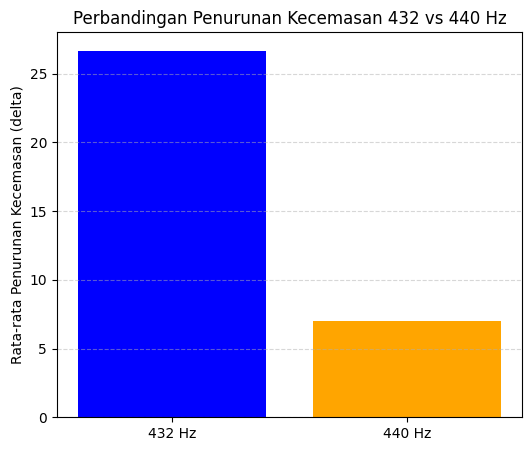

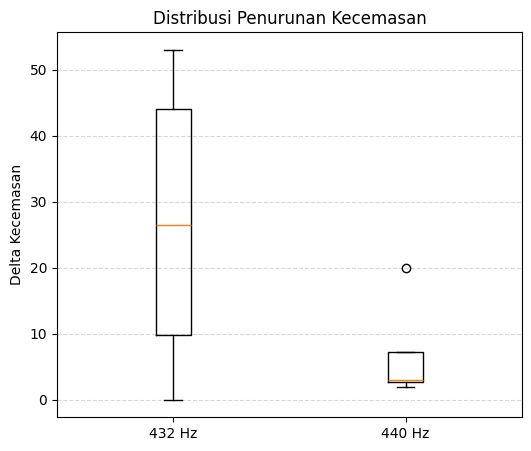


📁 Grafik disimpan sebagai:
plot_delta_mean.png
plot_delta_boxplot.png

===== 📌 KESIMPULAN OTOMATIS =====
✔ Kelompok 432 Hz mengalami penurunan kecemasan lebih besar.
❌ Perbedaan TIDAK signifikan (p ≥ 0.05).
Effect Size (Cohen's d): 1.1833655440231636
Interpretasi effect size:
→ Effect size besar


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# =====================================================
# 1. LOAD DATA
# =====================================================

file_path = "/content/drive/Shared drives/jurnal psd/STAI_Data.csv"
df = pd.read_csv(file_path)

print("📌 Data Loaded:")
print(df.head())

# =====================================================
# 2. DATA CLEANING
# =====================================================

df_clean = df[~df["subject"].astype(str).str.contains("subject", na=False)]

df_clean["pre_total"] = pd.to_numeric(df_clean["pre_total"], errors="coerce")
df_clean["post_total"] = pd.to_numeric(df_clean["post_total"], errors="coerce")
df_clean["delta"] = pd.to_numeric(df_clean["delta"], errors="coerce")
df_clean["audio_type"] = df_clean["audio_type"].astype(str).str.replace(".0", "", regex=False)
df_clean = df_clean[df_clean["pre_total"].between(20, 80)]
df_clean = df_clean[df_clean["post_total"].between(20, 80)]
df_clean = df_clean[df_clean["audio_type"].isin(["432", "440"])]

print("\n📌 Data Setelah Dibersihkan:")
print(df_clean)

# =====================================================
# 3. HITUNG MEAN DELTA PER KONDISI
# =====================================================

group_432 = df_clean[df_clean["audio_type"] == "432"]["delta"].dropna()
group_440 = df_clean[df_clean["audio_type"] == "440"]["delta"].dropna()

mean_432 = group_432.mean()
mean_440 = group_440.mean()

print("\n📊 Mean Penurunan Kecemasan:")
print("432 Hz :", mean_432)
print("440 Hz :", mean_440)
print("Selisih :", mean_432 - mean_440)

# =====================================================
# 4. UJI STATISTIK (Independent Samples)
# =====================================================

t_stat, p_val = ttest_ind(group_432, group_440, equal_var=False)

print("\n📌 UJI T (Independent Samples)")
print("t-statistic:", t_stat)
print("p-value:", p_val)

# =====================================================
# 5. EFFECT SIZE (Cohen’s d)
# =====================================================

def cohens_d(a, b):
    mean_diff = a.mean() - b.mean()
    pooled_sd = np.sqrt(((a.std() ** 2) + (b.std() ** 2)) / 2)
    return mean_diff / pooled_sd

d = cohens_d(group_432, group_440)

print("\n📌 EFFECT SIZE (Cohen's d):", d)

# =====================================================
# 6. VISUALISASI
# =====================================================

plt.figure(figsize=(6,5))
plt.bar(["432 Hz", "440 Hz"], [mean_432, mean_440], color=["blue", "orange"])
plt.ylabel("Rata-rata Penurunan Kecemasan (delta)")
plt.title("Perbandingan Penurunan Kecemasan 432 vs 440 Hz")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig("plot_delta_mean.png", dpi=200)
plt.show()

plt.figure(figsize=(6,5))
plt.boxplot([group_432, group_440], tick_labels=["432 Hz", "440 Hz"])
plt.ylabel("Delta Kecemasan")
plt.title("Distribusi Penurunan Kecemasan")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig("plot_delta_boxplot.png", dpi=200)
plt.show()

print("\nGrafik disimpan sebagai:")
print("plot_delta_mean.png")
print("plot_delta_boxplot.png")

# =====================================================
# 7. KESIMPULAN OTOMATIS
# =====================================================

print("\n===== KESIMPULAN OTOMATIS =====")

# Efektivitas
if mean_432 > mean_440:
    print("✔ Kelompok 432 Hz mengalami penurunan kecemasan lebih besar.")
else:
    print("✔ Kelompok 440 Hz mengalami penurunan kecemasan lebih besar.")

# Signifikansi
if p_val < 0.05:
    print("Perbedaan ini SIGNIFIKAN (p < 0.05).")
else:
    print("Perbedaan TIDAK signifikan (p ≥ 0.05).")

# Effect Size
print("Effect Size (Cohen's d):", d)
print("Interpretasi effect size:")
if abs(d) < 0.2:
    print("→ Effect size kecil")
elif abs(d) < 0.5:
    print("→ Effect size sedang")
else:
    print("→ Effect size besar")


1. mengambil data dari file PSD.csv di drive bersama dan data csv ini berasal dari input pengguna yang sebelumnya disimpan.
2. code juga mengubah kolom delta menjadi float serta membersihkan data dan memastikan semua kolom angka bener bener tipe numerik.
3. setelah itu menghitung rata rata delta untuk setiap kondisi audio dan menunjukkan seberapa besar penurunan kecemasan setelah mendengarkan audio
4. melakukan uji statistik yang digunakan untuk melihat rata rat dua kelompok berbeda dan memakai welchs t-test jika variasinya tidak sama
Output:
  - t-statistic = besarnya perbedaan
  - p-value = signifikansi perbedaan
5. selain itu, visualisasi yang dilakukan adalah
  - Bar Plot (perbandingan rata-rata)
  - Boxplot (distribusi data)
